**PCA** was used to reduce the dimensionality of the data while retaining most of the important information (variance).


The data was projected onto a lower-dimensional space defined by principal components.
The number of components was chosen to retain **threshold** (variable) value of the cumulative explained variance.(see Python cell 2 below for reference) to find the number of components that gives the best balance.

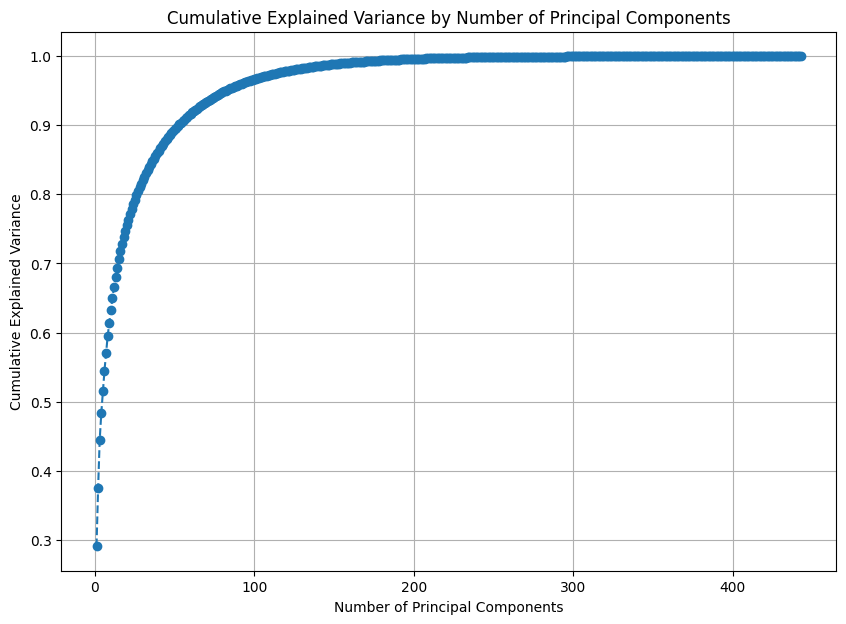

In [3]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# Load the data
X = pd.read_excel('../minmax.xlsx')
y = pd.read_csv('../idC_with_header.csv')['Label']

# Apply PCA
pca = PCA()
pca.fit(X)  # Fit PCA to the data

# Get the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

# Plot the cumulative explained variance ratio
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.grid(True)
plt.show()

To determine the number of components needed for a specific threshold.
Looking for the "elbow point" where adding more components provides diminishing returns.

In [2]:
# Find the number of components for 90% or 95% explained variance
threshold = 0.90
num_components = (cumulative_explained_variance >= threshold).argmax() + 1
print(f"Number of components to retain {threshold*100}% variance: {num_components} Components")

Number of components to retain 90.0% variance: 53 Components


**Reconstruction Error:**
While variance is the primary measure in PCA other approaches or metrics we can use to determine dimensionality reduction.

**Reconstruction Error:**
Measures how well the reduced data can reconstruct the original data.
Lower reconstruction error indicates that the reduced data retains most of the original information.

In [4]:
# Apply PCA with the selected number of components
pca = PCA(n_components=num_components)  # Use the number of components from Cell 2
X_reduced = pca.fit_transform(X)  # Fit and transform the data
X_reconstructed = pca.inverse_transform(X_reduced)

# Calculate reconstruction error
reconstruction_error = mean_squared_error(X, X_reconstructed)
print(f"Reconstruction Error: {reconstruction_error}")

Reconstruction Error: 0.007461635753739068


90% variance gave 53 Components and ~0.007 reconstrcuction error
95% variance gave 82 Components and 0.0038  reconstrcuction error
Better than 90%

Train Models and Print Accuracy

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the data
X = pd.read_excel('../minmax.xlsx')
y = pd.read_csv('../idC_with_header.csv')['Label']

# Apply PCA
n_components = 53  # Use the number of components for 95% variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

# Split the PCA-transformed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear', random_state=42)
}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on the test set
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Weighted average for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')  # Weighted average for multi-class
    f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted average for multi-class
    
    # Print results
    print(f"{model_name} Performance:")
    print(f"  - Accuracy:  {accuracy*100:.4f}%")
    print(f"  - Precision: {precision:.4f}")
    print(f"  - Recall:    {recall:.4f}")
    print(f"  - F1 Score:  {f1:.4f}")
    print()

Random Forest Performance:
  - Accuracy:  86.5169%
  - Precision: 0.8851
  - Recall:    0.8652
  - F1 Score:  0.8607

Naive Bayes Performance:
  - Accuracy:  83.1461%
  - Precision: 0.8782
  - Recall:    0.8315
  - F1 Score:  0.8331

SVM Performance:
  - Accuracy:  95.5056%
  - Precision: 0.9674
  - Recall:    0.9551
  - F1 Score:  0.9567



 **Feed PCA Results into a Genetic Algorithm (GA)**

 Using Random Forest in the Genetic Algorithm (GA) optimization is a strategic choic because Random Forest is chosen because it is robust, scalable, and benefits significantly from hyperparameter tuning

GA with RF

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

import numpy as np
from deap import base, creator, tools, algorithms

import warnings
warnings.filterwarnings("ignore")
# Load the data
X = pd.read_excel('../minmax.xlsx')
y = pd.read_csv('../idC_with_header.csv')['Label']
# Apply PCA
n_components = 53  # Use the number of components 53 or 82 for 90% or 95% variance Respectively
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)  # Transform the data into latent variables

# Split the PCA-transformed data into training and testing sets
X_train_latent, X_test_latent, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Define the fitness function for GA
def fitness_function(individual):
    n_estimators = int(individual[0])
    max_depth = int(individual[1])
    
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_latent, y_train, cv=stratified_kfold, scoring='accuracy')
    return np.mean(scores),

# GA setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

# Define the gene space (e.g., hyperparameter ranges)
toolbox.register("attr_int", np.random.randint, 10, 200)  # n_estimators
toolbox.register("attr_depth", np.random.randint, 1, 20)  # max_depth
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.attr_int, toolbox.attr_depth), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register GA operators
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutUniformInt, low=[10, 1], up=[200, 20], indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", fitness_function)

# Run the GA
population = toolbox.population(n=20)
ngen = 10  # Number of generations
hof = tools.HallOfFame(1)  # Keep the best individual
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=ngen, stats=None, halloffame=hof, verbose=True)

# Evaluate the best individual
best_individual = hof[0]
best_n_estimators = int(best_individual[0])
best_max_depth = int(best_individual[1])

# Print understandable results
print("\n=== Genetic Algorithm Results ===")
print(f"Best Hyperparameters:")
print(f"  - Number of Trees (n_estimators): {best_n_estimators}")
print(f"  - Maximum Depth of Trees (max_depth): {best_max_depth}")

# Train the final model with the best hyperparameters
final_model = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=42)
final_model.fit(X_train_latent, y_train)
final_accuracy = final_model.score(X_test_latent, y_test)

# Make predictions on the test set
y_pred = final_model.predict(X_test_latent)

# Print final model performance
print("\nFinal Model Performance:")
print(f"  - Accuracy on Test Data: {final_accuracy * 100:.2f}%")
# Print the latent variables and their count
print(f"Number of Latent Variables (Principal Components): {n_components}")


unique_classes = sorted(y_test.unique())
class_labels = [f"Class {i}" for i in unique_classes]  # Generate labels for the unique classes

# Generate the classification report
report = classification_report(y_test, y_pred, target_names=class_labels)

# Print the classification report
print("\nClassification Report:")
print(report)

gen	nevals
0  	20    
1  	20    
2  	14    
3  	14    
4  	16    
5  	20    
6  	14    
7  	20    
8  	15    
9  	15    
10 	14    

=== Genetic Algorithm Results ===
Best Hyperparameters:
  - Number of Trees (n_estimators): 180
  - Maximum Depth of Trees (max_depth): 12

Final Model Performance:
  - Accuracy on Test Data: 91.01%

Classification Report:
              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00         2
     Class 2       1.00      0.88      0.93         8
     Class 3       1.00      0.83      0.91         6
     Class 4       0.95      1.00      0.97        18
     Class 5       0.73      0.89      0.80         9
     Class 6       0.67      0.67      0.67         6
     Class 7       1.00      1.00      1.00         1
     Class 9       1.00      0.92      0.96        13
    Class 10       1.00      1.00      1.00         1
    Class 11       0.83      1.00      0.91         5
    Class 12       0.86      1.00      0.92      

GA with SVM

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import numpy as np
from deap import base, creator, tools, algorithms




import warnings
warnings.filterwarnings("ignore")



# Load the data
X = pd.read_excel('../minmax.xlsx')
y = pd.read_csv('../idC_with_header.csv')['Label']

# Apply PCA
n_components = 53  # Use the number of components for 95% variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)  # Transform the data into latent variables

# Split the PCA-transformed data into training and testing sets
X_train_latent, X_test_latent, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Define the fitness function for GA
def fitness_function(individual):
    C = 10 ** individual[0]  # Map to a range of 10^x for C
    gamma = 10 ** individual[1]  # Map to a range of 10^x for gamma
    
    model = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
    stratified_kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_latent, y_train, cv=stratified_kfold, scoring='accuracy')
    return np.mean(scores),

# GA setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

# Define the gene space (e.g., hyperparameter ranges)
toolbox.register("attr_float", np.random.uniform, -3, 3)  # Range for log10(C) and log10(gamma)
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.attr_float, toolbox.attr_float), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register GA operators
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", fitness_function)

# Run the GA
population = toolbox.population(n=20)
ngen = 10  # Number of generations
hof = tools.HallOfFame(1)  # Keep the best individual
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=ngen, stats=None, halloffame=hof, verbose=True)

# Evaluate the best individual
best_individual = hof[0]
best_C = 10 ** best_individual[0]
best_gamma = 10 ** best_individual[1]

# Print understandable results
print("\n=== Genetic Algorithm Results ===")
print(f"Best Hyperparameters:")
print(f"  - C (Regularization Parameter): {best_C}")
print(f"  - Gamma (Kernel Coefficient): {best_gamma}")

# Train the final model with the best hyperparameters
final_model = SVC(C=best_C, gamma=best_gamma, kernel='rbf', random_state=42)
final_model.fit(X_train_latent, y_train)
final_accuracy = final_model.score(X_test_latent, y_test)

# Make predictions on the test set
y_pred = final_model.predict(X_test_latent)

# Print final model performance
print("\nFinal Model Performance:")
print(f"  - Accuracy on Test Data: {final_accuracy * 100:.2f}%")

unique_classes = sorted(y_test.unique())
class_labels = [f"Class {i}" for i in unique_classes]  # Generate labels for the unique classes
# Print the latent variables and their count
print(f"Number of Latent Variables (Principal Components): {n_components}")
print("Latent Variables (First 5 Rows):")
print(X_pca[:5])  # Print the first 5 rows of the PCA-transformed data
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=class_labels)

# Print the classification report
print("\nClassification Report:")
print(report)

gen	nevals
0  	20    
1  	15    
2  	16    
3  	14    
4  	14    
5  	14    
6  	16    
7  	14    
8  	14    
9  	12    
10 	17    

=== Genetic Algorithm Results ===
Best Hyperparameters:
  - C (Regularization Parameter): 28.003283549113622
  - Gamma (Kernel Coefficient): 0.006983747650615116

Final Model Performance:
  - Accuracy on Test Data: 96.63%
Number of Latent Variables (Principal Components): 53
Latent Variables (First 5 Rows):
[[ 1.20993510e+00  2.95727859e-01  5.02295038e-01  3.22599536e+00
   1.77036279e+00 -1.41620371e-01  2.82503517e-01 -2.74292237e-01
  -9.47654183e-01 -4.44240826e-01 -3.97710268e-01 -9.86086369e-01
   5.93679224e-01 -7.35458400e-01  5.74948420e-01  1.08764123e+00
  -6.86438254e-01  4.41775204e-01  1.01616628e-01 -6.70766461e-01
   1.50757185e-01 -8.66286722e-01  9.86359570e-02 -8.31660852e-02
  -2.71893361e-01 -2.66804179e-01  8.79281623e-01  4.22869254e-01
  -2.41185493e-01  5.36156624e-02 -6.85635450e-02  1.11328926e-02
   8.52695231e-01  9.36866212e

GA with NBC

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import numpy as np
from deap import base, creator, tools, algorithms

import warnings
warnings.filterwarnings("ignore")

# Load the data
X = pd.read_excel('../minmax.xlsx')
y = pd.read_csv('../idC_with_header.csv')['Label']

# Apply PCA
n_components = 53  # Use the number of components for 95% variance
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)  # Transform the data into latent variables

# Split the PCA-transformed data into training and testing sets
X_train_latent, X_test_latent, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Define the fitness function for GA
def fitness_function(individual):
    # No hyperparameters to optimize for GaussianNB
    model = GaussianNB()
    stratified_kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_latent, y_train, cv=stratified_kfold, scoring='accuracy')
    return np.mean(scores),

# GA setup
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

# Define the gene space (dummy for NBC as no hyperparameters are optimized)
toolbox.register("attr_float", np.random.uniform, -3, 3)  # Placeholder
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.attr_float, toolbox.attr_float), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register GA operators
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", fitness_function)

# Run the GA
population = toolbox.population(n=20)
ngen = 10  # Number of generations
hof = tools.HallOfFame(1)  # Keep the best individual
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=ngen, stats=None, halloffame=hof, verbose=True)

# Train the final model with GaussianNB
final_model = GaussianNB()
final_model.fit(X_train_latent, y_train)
final_accuracy = final_model.score(X_test_latent, y_test)

# Make predictions on the test set
y_pred = final_model.predict(X_test_latent)

# Print final model performance
print("\nFinal Model Performance:")
print(f"  - Accuracy on Test Data: {final_accuracy * 100:.2f}%")

unique_classes = sorted(y_test.unique())
class_labels = [f"Class {i}" for i in unique_classes]  # Generate labels for the unique classes
# Print the latent variables and their count
print(f"Number of Latent Variables (Principal Components): {n_components}")
print("Latent Variables (First 5 Rows):")
print(X_pca[:5])  # Print the first 5 rows of the PCA-transformed data
# Generate the classification report
report = classification_report(y_test, y_pred, target_names=class_labels)

# Print the classification report
print("\nClassification Report:")
print(report)

gen	nevals
0  	20    
1  	11    
2  	16    
3  	6     
4  	13    
5  	19    
6  	17    
7  	15    
8  	19    
9  	15    
10 	18    

Final Model Performance:
  - Accuracy on Test Data: 86.52%
Number of Latent Variables (Principal Components): 53
Latent Variables (First 5 Rows):
[[ 1.2099351   0.29572786  0.50229502  3.22599582  1.77036362 -0.14162176
   0.2825056  -0.27428641 -0.94765087 -0.44420424 -0.39770383 -0.98608527
   0.59369147 -0.7355689   0.57483942  1.08775867 -0.68628554  0.44154459
   0.10147508 -0.67037018  0.1506442  -0.86558694  0.09838574 -0.08127175
  -0.27596423 -0.26371918  0.87836183  0.42058657 -0.23271363  0.05015215
  -0.0732247   0.02584201  0.84934154  0.93954168  0.46079259 -0.58646134
   0.31170131 -0.8299198  -0.10673185 -0.38005964 -0.05312988 -0.33416033
   0.50596081  0.4913156   0.36473582 -0.22679157 -0.45264647  0.61004977
   0.40552125 -0.8302712   0.12575122  0.01472247  0.31404674]
 [ 0.30020455 -0.49680183 -0.71712604  2.09368796  0.64628958 -0.3